<div style="padding: 20px; background-color: #f8f9f9; border-radius: 10px; border-left: 10px solid #2e86c1;">
    <h1 style="color: #2e86c1; margin-bottom: 5px;">🚀 Retailrocket Customer Segmentation</h1>
    <p style="font-size: 1.1em; color: #566573;">Unsupervised Learning Pipeline for Behavioral Clustering</p>
</div>

### Project Overview
This notebook implements a complete data science pipeline to segment customers based on their shopping behavior using the Retailrocket eCommerce dataset. We utilize **RFM (Recency, Frequency, Monetary)** analysis to transform raw event data into actionable customer profiles.

### Setup Dataset

In [1]:
from src.dataset import setup_data
setup_data()

Data is already available in the 'dataset' folder.


/Users/khanhba89/Documents/NEU/DA_Classification/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
import pandas as pd
import numpy as np
from src.analysis import plot_rfm_distributions, plot_rfm_correlation

data_paths = [
    './dataset/events.csv', 
    './dataset/item_properties_part1.csv', 
    './dataset/item_properties_part2.csv', 
    './dataset/category_tree.csv'
]

--- 
## 🛠️ Phase 1: Data Integration & Cleaning
In this phase, we aggregate multiple data sources (events, item properties, and category trees) into a single unified dataset. 

> **Key Operations:**
> - **Deduplication:** Removing redundant event logs.
> - **Temporal Alignment:** Extracting the latest properties for each item.
> - **ID Standardization:** Ensuring consistent data types across relational joins.

In [3]:
from src.data_integration import load_data, merge_data
# Load and Merge
csv_data = [load_data(p) for p in data_paths]
df_merged = merge_data(csv_data)

In this step, duplicated values have already been removed by DuckDB using the following query:

```sql
QUALIFY ROW_NUMBER() OVER (
    PARTITION BY itemid 
    ORDER BY timestamp DESC
) = 1

In [4]:
from src.cleaning_data import clean_data
# Cleaning Data
df_cleaned = clean_data(df_merged)
df_cleaned.head()

Original shape: (2756101, 7)
Cleaned shape: (2755641, 7)


,timestamp,visitorid,event,itemid,transactionid,categoryid,parentid
0,2015-09-10 18:51:44.978,235031,view,102751,0,572,1066
1,2015-09-11 01:39:15.563,1205343,view,84160,0,1244,500
2,2015-09-11 02:13:49.100,994820,view,90594,0,1366,1292
3,2015-09-11 02:05:44.148,1184758,view,293068,0,72,620
4,2015-09-11 01:59:09.283,1263207,view,151444,0,656,1125


In the `transactionid` column, customers who have not purchased any goods yet have missing values (`NaN`). To handle this issue, we replace all missing values with `"0"` for easier processing and analysis later.

For all other missing values (`NaN`) in the dataset, we fill them with `"-1"` to represent unknown or unavailable information.

--- 
## 🧠 Phase 2: Feature Engineering (RFM Analysis)
We calculate three core metrics for each user to capture their behavioral signature:

| Metric | Description | Weighting |
| :--- | :--- | :--- |
| **Recency** | Days since the user's last interaction | 1.0 |
| **Frequency** | Total number of interactions (Views, Carts, Purchases) | 1.0 |
| **Monetary** | Weighted Engagement Score | View=1, Cart=3, Trans=5 |

Since exact price data is unavailable, we use the **Engagement Score** as a proxy for the 'Monetary' value.

In [5]:
from src.features import calculate_rfm
# Calculate RFM Scores
rfm_df = calculate_rfm(df_cleaned)
rfm_df.head()

,visitorid,Recency,Frequency,Monetary
0,85734,52,1461,1573.0
1,162203,106,1,1.0
2,1144357,106,2,2.0
3,1102453,105,2,2.0
4,1183921,105,1,1.0


--- 
## 📊 Phase 2.5: RFM Exploratory Data Analysis
Before scaling, we visualize the raw distributions to identify skewness and analyze correlations between metrics.

In [6]:
rfm_df_subset = rfm_df.sample(frac=0.01, random_state=42)

Because the dataset is extremely large, containing approximately **2.7 million rows**, we use only **1% of the data** (around **27,000 rows**) to generate the EDA diagram.  

This sampling approach helps reduce processing complexity and improve visualization performance while still preserving the overall structure and relationships within the dataset.

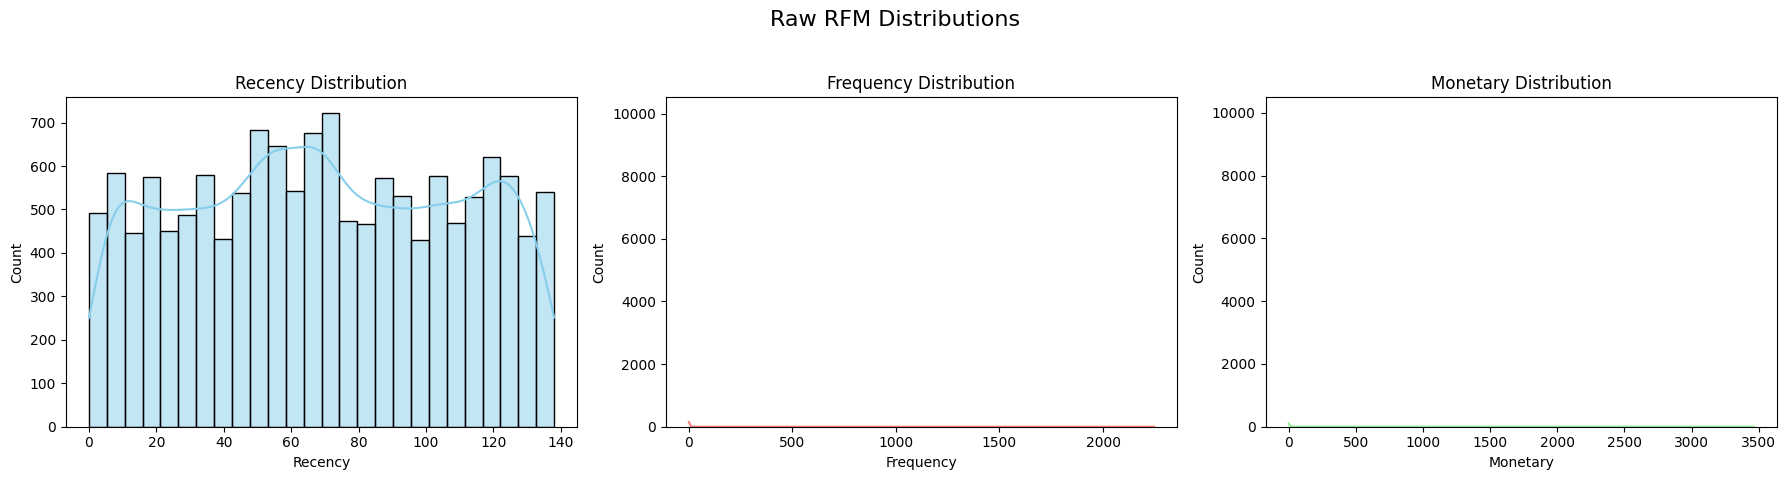

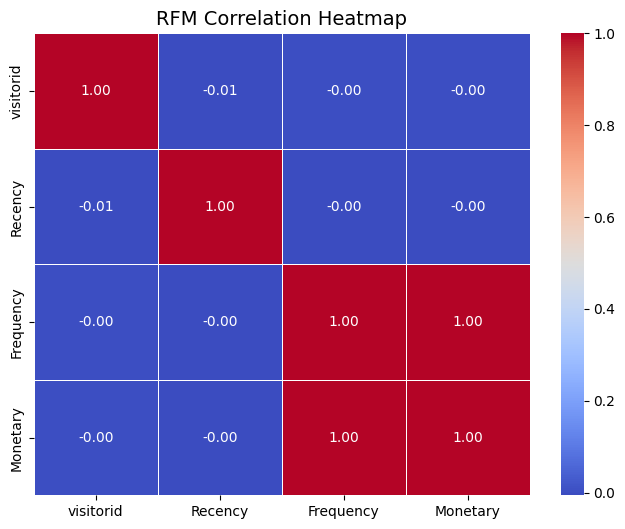

In [7]:
from src.analysis import plot_rfm_distributions, plot_rfm_correlation
# 1. Plot Raw Distributions
plot_rfm_distributions(rfm_df_subset, title="Raw RFM Distributions")

# 2. Plot Correlation Heatmap
plot_rfm_correlation(rfm_df_subset)

## Distribution Analysis (Raw Data)

The first set of charts illustrates the distribution of **Recency**, **Frequency**, and **Monetary** scores before applying any transformation.

### Recency
The Recency distribution is relatively uniform, with values spread across the **0–140 day range**. This indicates a consistent flow of returning visitors throughout the observation period, without a strong concentration of either very new or very inactive customers.

### Frequency & Monetary
Both Frequency and Monetary exhibit an extremely **right-skewed distribution**. Most visitors show very low engagement levels (near zero), while a small number of **highly active users** appear as significant outliers.

### Implication
Because of this heavy skewness, applying a **Logarithmic Transformation** is essential. Without normalization, distance-based clustering algorithms such as **K-Means** would be overly influenced by extreme values, resulting in poor cluster separation and less meaningful segmentation.

---

## Correlation Analysis (Heatmap)

The correlation heatmap highlights the linear relationships between the calculated features.

### Frequency vs. Monetary (`r = 1.00`)
Frequency and Monetary show a **perfect positive correlation**. This occurs because the Monetary metric is derived from the same weighted engagement scoring system used to calculate Frequency.

### Risk of Multicollinearity
Such a strong correlation introduces **multicollinearity**, meaning the clustering model may unintentionally give excessive importance to user engagement intensity by effectively counting the same behavioral pattern twice.

### Recency Independence
Recency has an almost **zero correlation** with both Frequency and Monetary (`r ≈ 0.00`). This suggests that the “time since last visit” captures a distinct behavioral dimension that is independent of user activity frequency or interaction value.

### VisitorID
As expected, `VisitorID` has no meaningful correlation with any behavioral features (`r ≈ 0.00`), confirming that it is a purely identifier-based attribute and should not contribute to the clustering model.

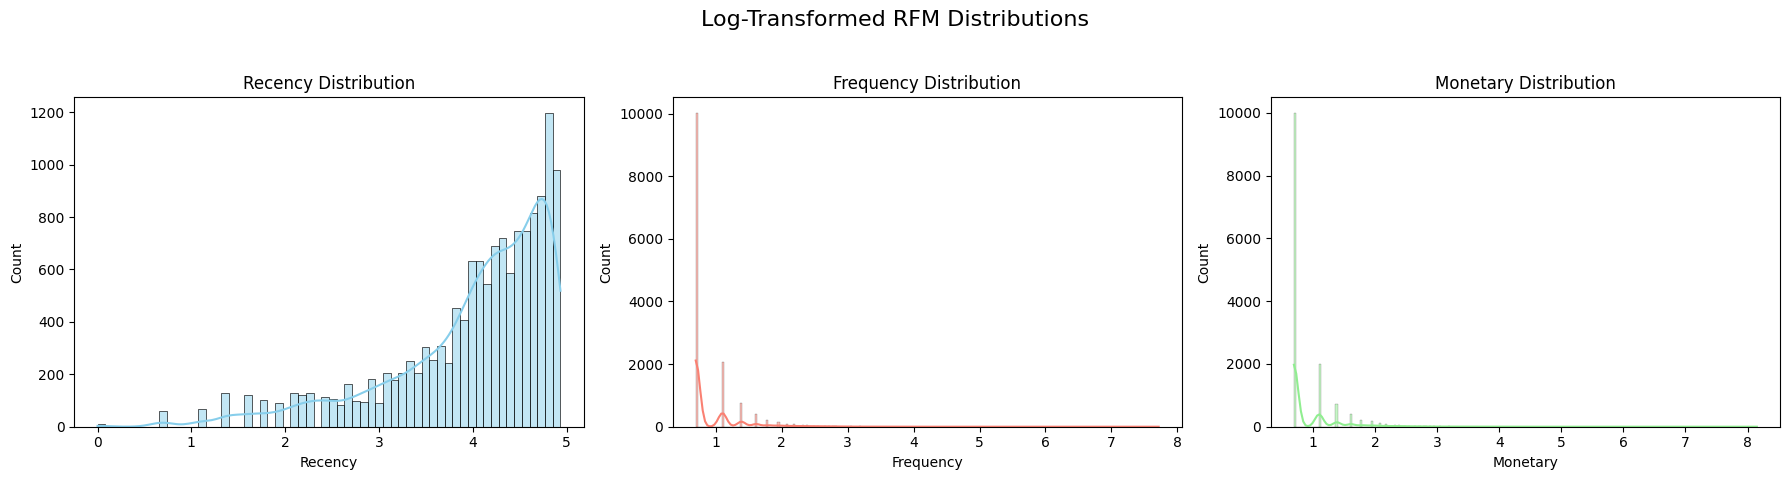

In [8]:
# 3. Plot Transformed Distributions (Log-Scale)
import numpy as np
rfm_log = np.log1p(rfm_df_subset)
plot_rfm_distributions(rfm_log, title="Log-Transformed RFM Distributions")

## Distribution Improvement

### Recency
The Recency distribution has shifted from being widely spread to becoming more concentrated around higher logarithmic values (`log 4.0 – 5.0`). This transformation helps emphasize the behavioral differences among customers who interacted recently.

### Frequency & Monetary
The logarithmic transformation successfully reduces the extreme right-skewness problem. Instead of appearing as a nearly vertical spike at zero, the data is now more evenly distributed across a wider range of values. This allows the model to better distinguish between different groups of users based on their engagement levels.

---

## Technical Significance

### Reduced Outlier Impact
Highly active customers (outliers) are pulled closer to the average user group, preventing the K-Means algorithm from being disproportionately influenced by a few exceptional individuals.

### Increased Sensitivity
The transformation allows the model to focus more on **relative behavioral changes** rather than absolute differences. For example, the difference between **1 and 10 purchases** becomes more meaningful than the difference between **1000 and 1010 purchases**.

---

## Conclusion

The dataset is now cleaner, more stable, and better suited for clustering analysis.  

After applying **StandardScaler**, all variables will share the same scale, ensuring a more balanced and fair clustering process across the **Recency (R)**, **Frequency (F)**, and **Monetary (M)** dimensions.

--- 
## ⚖️ Phase 3: Scaling & Outlier Handling
Clustering algorithms like **K-Means** are distance-based and sensitive to scale. We normalize our features to ensure each dimension contributes equally to the model.

1. **Log Transformation:** Normalizes highly skewed distributions (e.g., Frequency).
2. **Standard Scaling:** Centers data around zero with unit variance.

In [9]:
from src.features import prepare_features
# Apply Log Transformation and Scaling
features_scaled = prepare_features(rfm_df)

# Final Data Check
print("Final Feature Set Info:")
features_scaled.info()
features_scaled.head()

Final Feature Set Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407580 entries, 0 to 1407579
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   visitorid  1407580 non-null  float64
 1   Recency    1407580 non-null  float64
 2   Frequency  1407580 non-null  float64
 3   Monetary   1407580 non-null  float64
dtypes: float64(4)
memory usage: 43.0 MB


,visitorid,Recency,Frequency,Monetary
0,-1.798443,-0.015692,14.913567,13.989572
1,-1.160824,0.797668,-0.497638,-0.492174
2,0.792998,0.797668,0.449937,0.388396
3,0.755691,0.786797,0.449937,0.388396
4,0.826988,0.786797,-0.497638,-0.492174


--- 
## 🤖 Phase 4: Modeling & Evaluation
We implement **K-Means** as our primary clustering model. To determine the optimal number of segments, we use the **Elbow Method** and validate with **Silhouette Scores**.

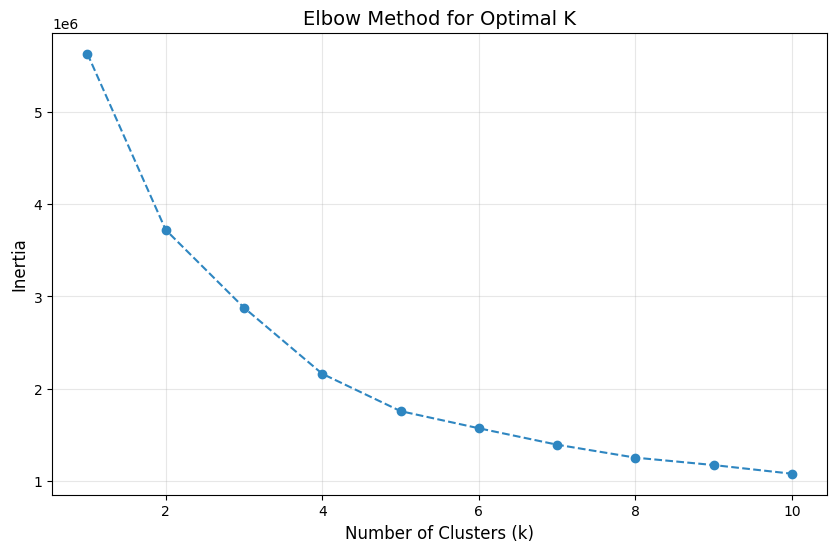

KeyboardInterrupt: 

In [10]:
from src.models import run_kmeans, plot_elbow, calculate_silhouette, run_dbscan

# 1. Find optimal K
plot_elbow(features_scaled)

# 2. Train final model (k=4, adjust based on plot)
k_optimal = 4
kmeans_labels = run_kmeans(features_scaled, k=k_optimal)

# 3. Evaluate
score = calculate_silhouette(features_scaled, kmeans_labels)
print(f"Silhouette Score for K={k_optimal}: {score:.3f}")

--- 
## 💡 Phase 5: Insights & Recommendations
Mathematical clusters are now translated into actionable business personas. We analyze the average **Recency, Frequency, and Monetary** traits for each group to define our strategy.

In [ ]:
from src.analysis import get_cluster_profiles, get_business_strategies

# 1. Generate Profiles
profiles = get_cluster_profiles(rfm_df, kmeans_labels)
display(profiles)

# 2. Strategic Recommendations
strategies = get_business_strategies(profiles)
display(strategies)

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,85.65,1.00,5.00,7036
1,60.67,34.93,174.67,195
2,16.13,1.12,5.58,2241
3,75.89,2.69,13.43,2097


,Persona,Strategy
Cluster,,
0,Window Shoppers,Retarget with popular items; Awareness campaigns.
1,At Risk / Churning,Send re-engagement emails; Discount codes for ...
2,Window Shoppers,Retarget with popular items; Awareness campaigns.
3,Window Shoppers,Retarget with popular items; Awareness campaigns.
